# Baseline LightGBM Centralisé — Pipeline complet avec timing MLflow

Notebook unique qui fusionne le preprocessing commun et l'entraînement LightGBM, avec tracking MLflow et **mesure systématique du temps de chaque étape**.

Sert de **référence centralisée** pour la comparaison avec la version distribuée (PySpark + SynapseML sur EMR). Conditions volontairement alignées : même dataset à sa taille réelle (pas de réduction mémoire), même split temporel, même métrique principale (AUC-PR), mêmes features.

**Architecture MLflow :**
- Un seul run wrappe l'intégralité du notebook → tous les timings et metrics sont attachés au même `run_id`
- Un context manager `timed_stage()` logge automatiquement `time_<stage>_s` dans MLflow
- Mémoire process (RSS) loggée à chaque jalon clé
- Tag `approach=centralized` pour matcher avec `approach=distributed_emr` côté Spark

**Pipeline :**
1. Chargement + merge (train_transaction × train_identity)
2. Drop colonnes >90% NaN et quasi-constantes
3. Feature engineering commun : normalisation D, features temporelles, TransactionAmt, email, M*, DeviceInfo
4. Feature engineering avancé : UID client, frequency encoding, group aggregations, features dérivées
5. Label encoding + imputation -999 + split temporel 60/20/20
6. Entraînement LightGBM
7. Réentraînement sur 100% + soumission Kaggle

## 1. Imports & configuration

In [1]:
!pip install mlflow psutil -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 892.1/892.1 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 10.7 MB/s eta 0:00:00


In [2]:
import os, gc, time, warnings, psutil
from contextlib import contextmanager
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import lightgbm as lgb

import mlflow
import mlflow.lightgbm

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)

DATA_DIR   = '/kaggle/input/datasets/ayushcl/ieee-fraud-detection-zip'
OUT_DIR    = '/kaggle/working/'
MLFLOW_DIR = f'{OUT_DIR}/mlruns'

PROC = psutil.Process(os.getpid())

print(os.listdir(DATA_DIR))

['sample_submission.csv', 'test_identity.csv', 'train_identity.csv', 'test_transaction.csv', 'train_transaction.csv']


## 2. MLflow setup + helpers de timing

### Pourquoi un seul run pour tout le notebook ?

Le run MLflow est démarré ici et **reste actif jusqu'à la dernière cellule**. Toutes les métriques (temps, mémoire, AUC) sont rattachées au même `run_id`. Avantage côté analyse : une ligne par exécution complète du pipeline dans `mlflow.search_runs()`, directement comparable à une exécution du pipeline distribué.

### Context manager `timed_stage`

Wrappe un bloc de code, mesure son wall-time, logge dans MLflow sous la clé `time_<stage_name>_s`. Logge aussi la RAM (RSS) après chaque stage sous `mem_after_<stage>_gb`.

In [3]:
mlflow.set_tracking_uri(f'file:{MLFLOW_DIR}')
mlflow.set_experiment('ieee_fraud_lgbm')

# Sécurité : si un run était resté ouvert d'une exécution précédente, on le ferme
if mlflow.active_run() is not None:
    mlflow.end_run()

print(f"Tracking URI : {mlflow.get_tracking_uri()}")
print(f"Experiment   : {mlflow.get_experiment_by_name('ieee_fraud_lgbm').name}")

2026/05/20 10:46:23 INFO mlflow.tracking.fluent: Experiment with name 'ieee_fraud_lgbm' does not exist. Creating a new experiment.


Tracking URI : file:/kaggle/working//mlruns
Experiment   : ieee_fraud_lgbm


In [4]:
# Stockage local des timings pour récap final (en plus du log MLflow)
TIMINGS = {}
MEMORY  = {}

def log_memory(label):
    """Logge la RAM process actuelle dans MLflow + dans le dict local."""
    rss_gb = PROC.memory_info().rss / 1024**3
    MEMORY[label] = rss_gb
    if mlflow.active_run() is not None:
        mlflow.log_metric(f'mem_{label}_gb', rss_gb)
    return rss_gb

@contextmanager
def timed_stage(name):
    """Mesure le wall-time d'un bloc, logge dans MLflow et affiche."""
    t0 = time.time()
    rss_before = PROC.memory_info().rss / 1024**3
    print(f'[{name}] start ... (RAM : {rss_before:.2f} GB)')
    try:
        yield
    finally:
        elapsed = time.time() - t0
        rss_after = PROC.memory_info().rss / 1024**3
        TIMINGS[name] = elapsed
        MEMORY[f'after_{name}'] = rss_after
        if mlflow.active_run() is not None:
            mlflow.log_metric(f'time_{name}_s', elapsed)
            mlflow.log_metric(f'mem_after_{name}_gb', rss_after)
        print(f'[{name}] done in {elapsed:.1f}s (RAM : {rss_after:.2f} GB, Δ {rss_after-rss_before:+.2f} GB)')

In [5]:
# Démarrage du run principal — reste actif jusqu'à la cellule finale
run = mlflow.start_run(run_name='lgbm_centralized_baseline')
RUN_ID = run.info.run_id
print(f'Run actif : {RUN_ID}')

# Tags pour la comparaison centralisé vs distribué
mlflow.set_tags({
    'approach'   : 'centralized',
    'framework'  : 'lightgbm',
    'dataset'    : 'ieee-cis',
    'split'      : 'temporal_60_20_20',
    'imputation' : 'sentinel_-999',
    'env'        : 'kaggle_single_node',
    'machine'    : 'kaggle_p100_16gb',
})

log_memory('start')

Run actif : ab43511a452c4f94832da4cddc1dd3bb


0.357818603515625

## 3. Chargement + merge

In [6]:
with timed_stage('load_merge'):
    train_tx = pd.read_csv(f'{DATA_DIR}/train_transaction.csv')
    train_id = pd.read_csv(f'{DATA_DIR}/train_identity.csv')
    test_tx  = pd.read_csv(f'{DATA_DIR}/test_transaction.csv')
    test_id  = pd.read_csv(f'{DATA_DIR}/test_identity.csv')

    # Test identity utilise '-' au lieu de '_' dans les noms de colonnes
    test_id.columns = [c.replace('-', '_') for c in test_id.columns]

    train       = train_tx.merge(train_id, how='left', on='TransactionID')
    test_kaggle = test_tx.merge(test_id,   how='left', on='TransactionID')
    del train_tx, train_id, test_tx, test_id; gc.collect()

mem_train_mb = train.memory_usage(deep=True).sum() / 1024**2
mem_test_mb  = test_kaggle.memory_usage(deep=True).sum() / 1024**2

mlflow.log_params({
    'raw_train_rows' : len(train),
    'raw_test_rows'  : len(test_kaggle),
    'raw_train_cols' : train.shape[1],
    'raw_test_cols'  : test_kaggle.shape[1],
})
mlflow.log_metrics({
    'mem_train_mb_raw' : mem_train_mb,
    'mem_test_mb_raw'  : mem_test_mb,
})

print(f'Train       : {train.shape}       | mémoire : {mem_train_mb:.0f} MB')
print(f'Test Kaggle : {test_kaggle.shape} | mémoire : {mem_test_mb:.0f} MB')
print(f'Fraud rate  : {train.isFraud.mean():.4f}')

[load_merge] start ... (RAM : 0.36 GB)
[load_merge] done in 51.9s (RAM : 5.16 GB, Δ +4.80 GB)
Train       : (590540, 434)       | mémoire : 2514 MB
Test Kaggle : (506691, 433) | mémoire : 2164 MB
Fraud rate  : 0.0350


## 4. Drop des colonnes >90% NaN et quasi-constantes

In [7]:
with timed_stage('drop_columns'):
    missing_pct = train.isnull().mean()
    cols_drop_nan = missing_pct[missing_pct > 0.90].index.tolist()
    train.drop(columns=cols_drop_nan, inplace=True)
    test_kaggle.drop(columns=[c for c in cols_drop_nan if c in test_kaggle.columns], inplace=True)

    near_const = []
    for c in train.columns:
        if c in ('isFraud', 'TransactionID'):
            continue
        if train[c].value_counts(dropna=False, normalize=True).iloc[0] > 0.99:
            near_const.append(c)
    train.drop(columns=near_const, inplace=True)
    test_kaggle.drop(columns=[c for c in near_const if c in test_kaggle.columns], inplace=True)

print(f'{len(cols_drop_nan)} colonnes >90% NaN droppées')
print(f'{len(near_const)} colonnes quasi-constantes droppées')
print(f'Shape : train {train.shape} | test {test_kaggle.shape}')

mlflow.log_params({
    'cols_dropped_high_nan'    : len(cols_drop_nan),
    'cols_dropped_near_const'  : len(near_const),
})

[drop_columns] start ... (RAM : 5.16 GB)
[drop_columns] done in 7.6s (RAM : 5.02 GB, Δ -0.14 GB)
12 colonnes >90% NaN droppées
15 colonnes quasi-constantes droppées
Shape : train (590540, 407) | test (506691, 406)


## 5. Feature engineering commun

Les 6 étapes communes (normalisation D, features temporelles, TransactionAmt, email, M*, DeviceInfo) sont regroupées sous un seul `timed_stage` pour avoir une mesure globale comparable à la phase équivalente côté Spark (un même `Transformer` ou pipeline Spark fait souvent l'ensemble).

In [8]:
with timed_stage('fe_common'):
    # 5.1 Normalisation des colonnes D (anti-drift temporel)
    for i in range(1, 16):
        col = f'D{i}'
        if col not in train.columns or i in (1, 2, 3, 5, 9):
            continue
        train[col]       = (train[col]       - train['TransactionDT']       / np.float32(86400)).astype(np.float32)
        test_kaggle[col] = (test_kaggle[col] - test_kaggle['TransactionDT'] / np.float32(86400)).astype(np.float32)

    # 5.2 Features temporelles
    START = pd.Timestamp('2017-12-01')
    for df in [train, test_kaggle]:
        dt = df['TransactionDT'].apply(lambda s: START + pd.Timedelta(seconds=s))
        df['DT_hour']    = dt.dt.hour.astype(np.int8)
        df['DT_weekday'] = dt.dt.weekday.astype(np.int8)
        df['DT_day']     = dt.dt.day.astype(np.int8)
        df['DT_month']   = dt.dt.month.astype(np.int8)
        df['DT_M']       = ((dt.dt.year - 2017) * 12 + dt.dt.month).astype(np.int8)

    # 5.3 TransactionAmt : log + cents
    for df in [train, test_kaggle]:
        df['TransactionAmt_log']   = np.log1p(df['TransactionAmt']).astype(np.float32)
        df['TransactionAmt_cents'] = (df['TransactionAmt'] - np.floor(df['TransactionAmt'])).astype(np.float32)

    # 5.4 Email : binning + suffix + email_check
    emails = {
        'gmail.com':'google',   'gmail':'google',
        'yahoo.com':'yahoo',    'yahoo.fr':'yahoo',
        'hotmail.com':'microsoft', 'hotmail.fr':'microsoft',
        'outlook.com':'microsoft', 'live.com':'microsoft', 'msn.com':'microsoft',
        'aol.com':'aol',
        'icloud.com':'apple', 'me.com':'apple', 'mac.com':'apple',
        'anonymous.com':'anonymous'
    }
    for df in [train, test_kaggle]:
        for c in ['P_emaildomain', 'R_emaildomain']:
            df[f'{c}_bin']    = df[c].map(emails).fillna('other')
            df[f'{c}_suffix'] = df[c].astype(str).str.rsplit('.', n=1).str[-1]
        df['email_check'] = ((df['P_emaildomain'] == df['R_emaildomain']) &
                            (df['P_emaildomain'].notna())).astype(np.int8)

    # 5.5 M columns : M_sum, M_na
    M_cols = [c for c in ['M1','M2','M3','M5','M6','M7','M8','M9'] if c in train.columns]
    for df in [train, test_kaggle]:
        df['M_na'] = df[M_cols].isna().sum(axis=1).astype(np.int8)
        mm = df[M_cols].replace({'T': 1, 'F': 0})
        df['M_sum'] = pd.to_numeric(mm.stack(), errors='coerce').unstack().sum(axis=1).astype(np.int8)

    # 5.6 DeviceInfo / id_30 / id_31 split en device + version
    def split_device(s):
        s = str(s).lower() if pd.notna(s) else 'unknown'
        dev = ''.join(ch for ch in s if ch.isalpha()) or 'unknown'
        ver = ''.join(ch for ch in s if ch.isnumeric()) or '0'
        return dev, ver

    for df in [train, test_kaggle]:
        for col in ['DeviceInfo', 'id_30', 'id_31']:
            if col not in df.columns:
                continue
            parts = df[col].apply(split_device)
            df[f'{col}_device']  = parts.apply(lambda x: x[0])
            df[f'{col}_version'] = parts.apply(lambda x: x[1])

print(f'Shape après FE commun : train {train.shape} | test {test_kaggle.shape}')

[fe_common] start ... (RAM : 5.02 GB)
[fe_common] done in 28.0s (RAM : 5.38 GB, Δ +0.36 GB)
Shape après FE commun : train (590540, 427) | test (506691, 426)


## 6. Feature engineering avancé (UID + agrégations)

UID client (`card1 + addr1 + D1n`), frequency encoding, group aggregations par UID et features dérivées (ratio, z-score, time delta). C'est la phase la plus coûteuse en CPU côté centralisé — utile à isoler dans le timing pour la comparaison avec les `groupBy + agg` Spark.

In [9]:
with timed_stage('fe_advanced'):
    # 6.1 UID client
    for df in [train, test_kaggle]:
        df['day'] = df['TransactionDT'] // (24 * 60 * 60)
        df['D1n'] = df['day'] - df['D1']
        df['uid'] = (df['card1'].astype(str) + '_' +
                     df['addr1'].astype(str) + '_' +
                     df['D1n'].astype(str))
        df['card1_addr1']         = df['card1'].astype(str) + '_' + df['addr1'].astype(str)
        df['card1_addr1_P_email'] = df['card1_addr1'] + '_' + df['P_emaildomain'].astype(str)
        df['outsider15'] = (np.abs(df['D1'].fillna(0) - df['D15'].fillna(0)) > 3).astype(np.int8)

    n_uid_train = train['uid'].nunique()
    n_uid_test  = test_kaggle['uid'].nunique()
    print(f"UIDs uniques train : {n_uid_train:,}")
    print(f"UIDs uniques test  : {n_uid_test:,}")

    # 6.2 Frequency encoding (sur train + test combinés)
    FE_COLS = ['card1','card2','card3','card5','addr1','addr2',
               'P_emaildomain','R_emaildomain',
               'uid','card1_addr1','card1_addr1_P_email']
    FE_COLS = [c for c in FE_COLS if c in train.columns]

    full_fe = pd.concat([train, test_kaggle], ignore_index=True)
    for c in FE_COLS:
        vc = full_fe[c].astype(str).value_counts(dropna=False, normalize=True).to_dict()
        train[f'{c}_FE']       = train[c].astype(str).map(vc).astype(np.float32)
        test_kaggle[f'{c}_FE'] = test_kaggle[c].astype(str).map(vc).astype(np.float32)
    del full_fe; gc.collect()

    # 6.3 Group aggregations par UID
    AGG_COLS = ['TransactionAmt','D4','D9','D10','D15','C1','C13','C14']
    AGG_COLS = [c for c in AGG_COLS if c in train.columns]

    full_agg = pd.concat([train, test_kaggle], ignore_index=True)
    for col in AGG_COLS:
        agg = full_agg.groupby('uid')[col].agg(['mean','std'])
        mean_map = agg['mean'].to_dict()
        std_map  = agg['std'].to_dict()
        for df in [train, test_kaggle]:
            df[f'{col}_uid_mean'] = df['uid'].map(mean_map).astype(np.float32)
            df[f'{col}_uid_std']  = df['uid'].map(std_map).astype(np.float32)
            df[f'{col}_uid_diff'] = (df[col] - df[f'{col}_uid_mean']).astype(np.float32)
    del full_agg; gc.collect()

    # 6.4 Features dérivées : ratio, z-score, activité, time delta
    for df in [train, test_kaggle]:
        df['amt_ratio_uid']  = (df['TransactionAmt'] /
                                (df['TransactionAmt_uid_mean'] + 1)).astype(np.float32)
        df['amt_zscore_uid'] = ((df['TransactionAmt'] - df['TransactionAmt_uid_mean']) /
                                (df['TransactionAmt_uid_std'].fillna(1) + 1)).astype(np.float32)

    for df in [train, test_kaggle]:
        df['uid_nb_tx']    = df.groupby('uid')['TransactionID'].transform('count').astype(np.int32)
        df['uid_nb_cards'] = df.groupby('uid')['card1'].transform('nunique').astype(np.int16)

    for df in [train, test_kaggle]:
        df.sort_values(['uid','TransactionDT'], inplace=True)
        df['uid_time_delta'] = df.groupby('uid')['TransactionDT'].diff().astype(np.float32)
        df['uid_time_delta'].fillna(-1, inplace=True)
        df.sort_index(inplace=True)

mlflow.log_params({
    'n_uid_train': n_uid_train,
    'n_uid_test' : n_uid_test,
    'n_fe_cols'  : len(FE_COLS),
    'n_agg_cols' : len(AGG_COLS),
})
print(f'Shape après FE avancé : train {train.shape} | test {test_kaggle.shape}')

[fe_advanced] start ... (RAM : 5.38 GB)
UIDs uniques train : 217,850
UIDs uniques test  : 196,187
[fe_advanced] done in 71.6s (RAM : 5.41 GB, Δ +0.03 GB)
Shape après FE avancé : train (590540, 473) | test (506691, 472)


## 7. Drop UID brut + label encoding des catégorielles

In [10]:
with timed_stage('label_encoding'):
    DROP = ['uid','card1_addr1','card1_addr1_P_email','day','D1n']
    for df in [train, test_kaggle]:
        df.drop(columns=[c for c in DROP if c in df.columns], inplace=True)

    cat_cols = [c for c in train.columns if train[c].dtype == 'object']
    for col in cat_cols:
        le = LabelEncoder()
        combined = pd.concat([train[col], test_kaggle[col]]).astype(str).fillna('missing')
        le.fit(combined)
        train[col]       = le.transform(train[col].astype(str).fillna('missing')).astype(np.int32)
        test_kaggle[col] = le.transform(test_kaggle[col].astype(str).fillna('missing')).astype(np.int32)

print(f'{len(cat_cols)} colonnes catégorielles label-encodées')
mlflow.log_param('n_cat_cols_encoded', len(cat_cols))

[label_encoding] start ... (RAM : 5.41 GB)
[label_encoding] done in 27.8s (RAM : 5.17 GB, Δ -0.24 GB)
39 colonnes catégorielles label-encodées


39

## 8. Imputation -999 + split temporel 60/20/20

In [11]:
with timed_stage('impute_split'):
    train.fillna(-999, inplace=True)
    test_kaggle.fillna(-999, inplace=True)

    FEATURES = [c for c in train.columns if c not in ('isFraud','TransactionID','TransactionDT','DT_M')]

    train_sorted = train.sort_values('TransactionDT').reset_index(drop=True)
    n = len(train_sorted)
    i1, i2 = int(n * 0.6), int(n * 0.8)

    X_tr,  y_tr  = train_sorted.loc[:i1-1,   FEATURES], train_sorted.loc[:i1-1,   'isFraud']
    X_val, y_val = train_sorted.loc[i1:i2-1, FEATURES], train_sorted.loc[i1:i2-1, 'isFraud']
    X_te,  y_te  = train_sorted.loc[i2:,     FEATURES], train_sorted.loc[i2:,     'isFraud']

print(f'Nombre total de features : {len(FEATURES)}')
print(f'Train : {X_tr.shape}  | fraud rate : {y_tr.mean():.4f}')
print(f'Val   : {X_val.shape} | fraud rate : {y_val.mean():.4f}')
print(f'Test  : {X_te.shape}  | fraud rate : {y_te.mean():.4f}')

mlflow.log_params({
    'num_features'    : len(FEATURES),
    'n_train'         : len(X_tr),
    'n_val'           : len(X_val),
    'n_test'          : len(X_te),
    'fraud_rate_train': float(y_tr.mean()),
    'fraud_rate_val'  : float(y_val.mean()),
    'fraud_rate_test' : float(y_te.mean()),
})

# Empreinte mémoire des splits
mem_x_tr_mb  = X_tr.memory_usage(deep=True).sum() / 1024**2
mem_x_val_mb = X_val.memory_usage(deep=True).sum() / 1024**2
mem_x_te_mb  = X_te.memory_usage(deep=True).sum() / 1024**2
mlflow.log_metrics({
    'mem_X_tr_mb'  : mem_x_tr_mb,
    'mem_X_val_mb' : mem_x_val_mb,
    'mem_X_te_mb'  : mem_x_te_mb,
})
print(f'\nMémoire X_tr  : {mem_x_tr_mb:.0f} MB')
print(f'Mémoire X_val : {mem_x_val_mb:.0f} MB')
print(f'Mémoire X_te  : {mem_x_te_mb:.0f} MB')

[impute_split] start ... (RAM : 5.17 GB)
[impute_split] done in 13.5s (RAM : 12.31 GB, Δ +7.14 GB)
Nombre total de features : 464
Train : (354324, 464)  | fraud rate : 0.0338
Val   : (118108, 464) | fraud rate : 0.0390
Test  : (118108, 464)  | fraud rate : 0.0344

Mémoire X_tr  : 1115 MB
Mémoire X_val : 372 MB
Mémoire X_te  : 372 MB


## 9. Fonction d'évaluation (AUC-ROC + AUC-PR)

In [12]:
results = []

def evaluate(y_true, y_pred, name, split_name, ax_roc=None, ax_pr=None, color=None):
    auc_roc = roc_auc_score(y_true, y_pred)
    auc_pr  = average_precision_score(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    pr,  rc,  _ = precision_recall_curve(y_true, y_pred)
    if ax_roc is not None: ax_roc.plot(fpr, tpr, color=color, label=f'{name} (AUC={auc_roc:.4f})')
    if ax_pr  is not None: ax_pr.plot(rc,  pr,  color=color, label=f'{name} (AP={auc_pr:.4f})')
    print(f'  {split_name:5s} | AUC-ROC : {auc_roc:.4f} | AUC-PR : {auc_pr:.4f}')
    results.append({'model': name, 'split': split_name, 'auc_roc': auc_roc, 'auc_pr': auc_pr})
    return auc_roc, auc_pr

## 10. Entraînement LightGBM

Hyperparamètres alignés sur les solutions Kaggle de référence (`num_leaves=512`, `lr=0.03`, `feature_fraction=0.5`, `early_stopping=150`). Les temps de training et d'inférence sont mesurés séparément — côté distribué, la phase d'inférence est aussi très différente (Spark broadcast du modèle vs distribution des données).

In [13]:
def auc_pr_lgb(y_pred, dataset):
    return 'auc_pr', average_precision_score(dataset.get_label(), y_pred), True

lgb_params = {
    'objective': 'binary',
    'metric': 'None',
    'learning_rate': 0.03,
    'num_leaves': 512,
    'min_child_samples': 80,
    'feature_fraction': 0.5,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'is_unbalance': True,
    'verbose': -1,
}

mlflow.log_params(lgb_params)
mlflow.log_params({
    'num_boost_round': 3000,
    'early_stopping' : 150,
})

dtr = lgb.Dataset(X_tr,  y_tr)
dvl = lgb.Dataset(X_val, y_val)

with timed_stage('train_lgbm'):
    model_lgb = lgb.train(
        lgb_params, dtr,
        num_boost_round=3000,
        valid_sets=[dvl],
        feval=auc_pr_lgb,
        callbacks=[lgb.early_stopping(150), lgb.log_evaluation(200)],
    )

with timed_stage('inference_val'):
    pred_lgb_val = model_lgb.predict(X_val)

with timed_stage('inference_test'):
    pred_lgb_te = model_lgb.predict(X_te)

print('\nLightGBM :')
auc_roc_val, auc_pr_val = evaluate(y_val, pred_lgb_val, 'LightGBM', 'val')
auc_roc_te,  auc_pr_te  = evaluate(y_te,  pred_lgb_te,  'LightGBM', 'test')

mlflow.log_metrics({
    'val_auc_roc'   : auc_roc_val,
    'val_auc_pr'    : auc_pr_val,
    'test_auc_roc' : auc_roc_te,
    'test_auc_pr'  : auc_pr_te,
    'best_iteration': model_lgb.best_iteration,
})

mlflow.lightgbm.log_model(model_lgb, artifact_path='model_holdout')

print(f'\nBest iteration : {model_lgb.best_iteration}')

[train_lgbm] start ... (RAM : 12.31 GB)
Training until validation scores don't improve for 150 rounds
[200]	valid_0's auc_pr: 0.672348
[400]	valid_0's auc_pr: 0.703139
[600]	valid_0's auc_pr: 0.711326
[800]	valid_0's auc_pr: 0.715668
[1000]	valid_0's auc_pr: 0.718541
[1200]	valid_0's auc_pr: 0.720338
[1400]	valid_0's auc_pr: 0.7216
[1600]	valid_0's auc_pr: 0.723072
[1800]	valid_0's auc_pr: 0.724096
[2000]	valid_0's auc_pr: 0.724562
Early stopping, best iteration is:
[1998]	valid_0's auc_pr: 0.724646
[train_lgbm] done in 965.0s (RAM : 12.73 GB, Δ +0.42 GB)
[inference_val] start ... (RAM : 12.73 GB)
[inference_val] done in 54.4s (RAM : 12.73 GB, Δ +0.00 GB)
[inference_test] start ... (RAM : 12.73 GB)
[inference_test] done in 56.1s (RAM : 12.73 GB, Δ +0.00 GB)

LightGBM :
  val   | AUC-ROC : 0.9467 | AUC-PR : 0.7246


2026/05/20 11:07:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  test  | AUC-ROC : 0.9138 | AUC-PR : 0.5839

Best iteration : 1998


## 11. Courbes ROC et PR sur le test hold-out

  test  | AUC-ROC : 0.9138 | AUC-PR : 0.5839


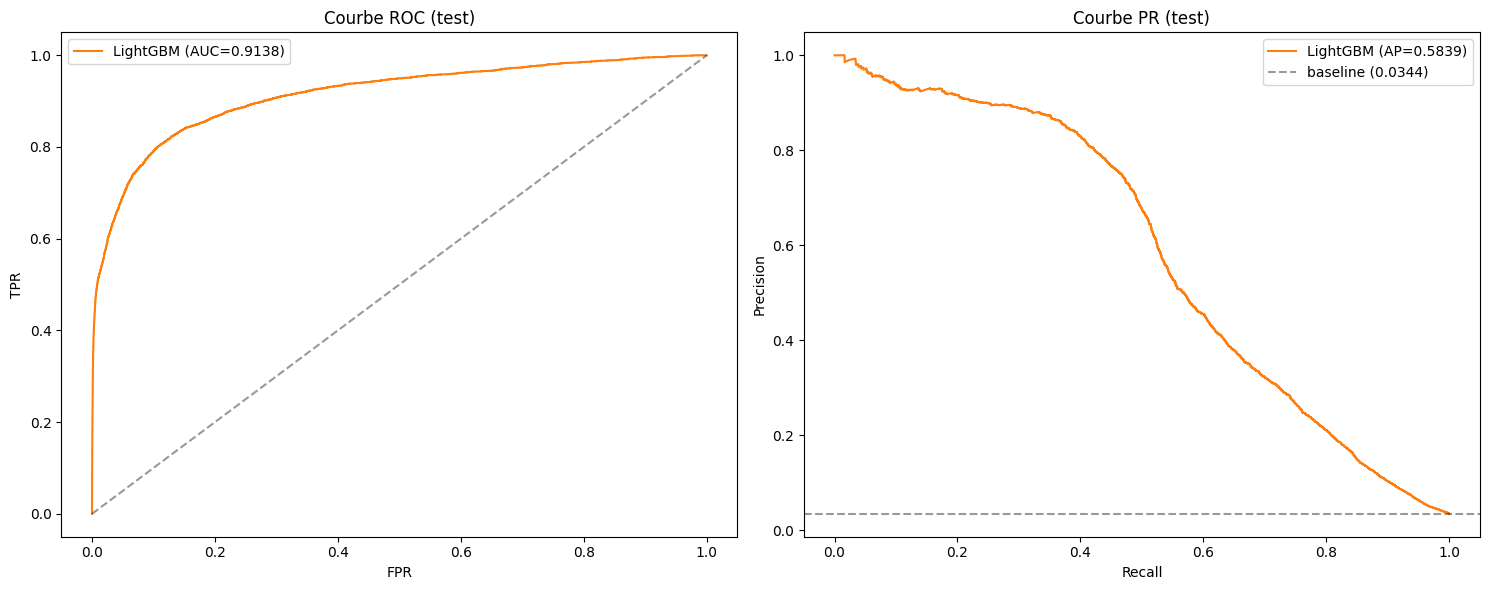

auc_pr            auc_roc          
split         test       val     test       val
model                                          
LightGBM  0.583927  0.724646  0.91375  0.946673

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
evaluate(y_te, pred_lgb_te, 'LightGBM', 'test', ax1, ax2, 'C1')

ax1.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.set_title('Courbe ROC (test)'); ax1.legend()

ax2.axhline(y_te.mean(), color='k', ls='--', alpha=0.4, label=f'baseline ({y_te.mean():.4f})')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Courbe PR (test)'); ax2.legend()

plt.tight_layout()
curves_path = f'{OUT_DIR}/curves_lgbm.png'
plt.savefig(curves_path, dpi=120, bbox_inches='tight')
plt.show()

mlflow.log_artifact(curves_path)
pd.DataFrame(results).pivot_table(index='model', columns='split', values=['auc_roc','auc_pr'])

## 12. Feature importance (top 30, gain)

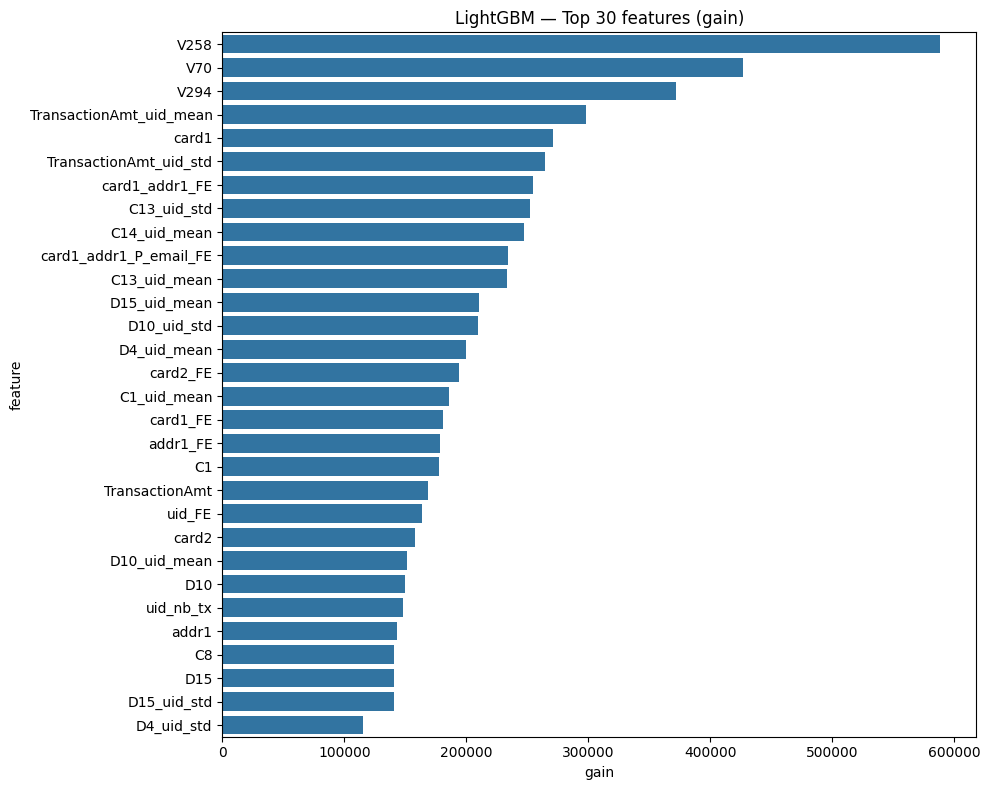

Features UID/magic dans le top 30 : 19/30


In [15]:
imp = pd.DataFrame({
    'feature': FEATURES,
    'gain'   : model_lgb.feature_importance(importance_type='gain'),
    'split'  : model_lgb.feature_importance(importance_type='split'),
}).sort_values('gain', ascending=False)

top30 = imp.head(30)

plt.figure(figsize=(10, 8))
sns.barplot(data=top30, y='feature', x='gain')
plt.title('LightGBM — Top 30 features (gain)')
plt.tight_layout()
fi_png = f'{OUT_DIR}/feature_importance_lgbm.png'
plt.savefig(fi_png, dpi=120, bbox_inches='tight')
plt.show()

fi_csv = f'{OUT_DIR}/feature_importance_lgbm.csv'
imp.to_csv(fi_csv, index=False)

mlflow.log_artifact(fi_csv)
mlflow.log_artifact(fi_png)

magic_mask = top30.feature.str.contains('uid|zscore|ratio|_FE|_diff|time_delta|outsider|nb_tx|nb_cards', regex=True)
print(f'Features UID/magic dans le top 30 : {magic_mask.sum()}/30')

## 15. Récap des timings + fermeture du run

Le temps total `time_pipeline_total_s` est calculé comme la somme de toutes les étapes et loggé en metric agrégée — c'est l'équivalent du temps wall-clock du pipeline complet.

In [16]:
# Mémoire finale
log_memory('end')

# Temps total = somme des stages
time_pipeline_total_s = sum(TIMINGS.values())
mlflow.log_metric('time_pipeline_total_s', time_pipeline_total_s)

# Peak memory observée
peak_mem_gb = max(MEMORY.values())
mlflow.log_metric('mem_peak_gb', peak_mem_gb)

# Récap visuel
print('=' * 60)
print('RÉCAP TIMINGS (centralisé)')
print('=' * 60)
for stage, t in TIMINGS.items():
    pct = 100 * t / time_pipeline_total_s
    print(f'  {stage:25s} : {t:7.1f}s  ({pct:5.1f}%)')
print('-' * 60)
print(f'  {"TOTAL":25s} : {time_pipeline_total_s:7.1f}s  (100.0%)')
print()
print(f'Peak RAM observée : {peak_mem_gb:.2f} GB')
print(f'Run ID            : {RUN_ID}')

RÉCAP TIMINGS (centralisé)
  load_merge                :    51.9s  (  4.1%)
  drop_columns              :     7.6s  (  0.6%)
  fe_common                 :    28.0s  (  2.2%)
  fe_advanced               :    71.6s  (  5.6%)
  label_encoding            :    27.8s  (  2.2%)
  impute_split              :    13.5s  (  1.1%)
  train_lgbm                :   965.0s  ( 75.6%)
  inference_val             :    54.4s  (  4.3%)
  inference_test            :    56.1s  (  4.4%)
------------------------------------------------------------
  TOTAL                     :  1276.0s  (100.0%)

Peak RAM observée : 12.73 GB
Run ID            : ab43511a452c4f94832da4cddc1dd3bb


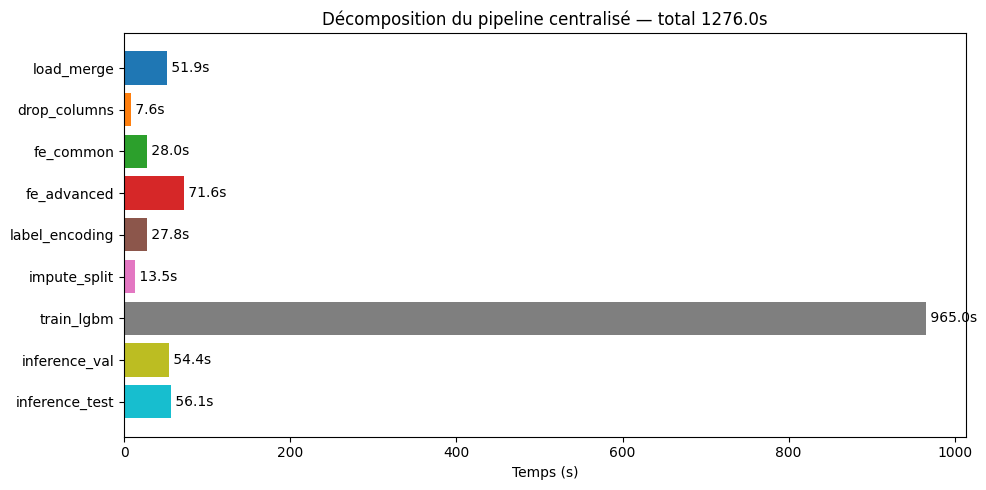

In [17]:
# Bar chart des timings (loggé comme artifact)
fig, ax = plt.subplots(figsize=(10, 5))
stages = list(TIMINGS.keys())
times  = [TIMINGS[s] for s in stages]
colors = plt.cm.tab10(np.linspace(0, 1, len(stages)))
ax.barh(stages, times, color=colors)
for i, t in enumerate(times):
    ax.text(t, i, f' {t:.1f}s', va='center')
ax.set_xlabel('Temps (s)')
ax.set_title(f'Décomposition du pipeline centralisé — total {time_pipeline_total_s:.1f}s')
ax.invert_yaxis()
plt.tight_layout()
timings_png = f'{OUT_DIR}/timings_breakdown.png'
plt.savefig(timings_png, dpi=120, bbox_inches='tight')
plt.show()

mlflow.log_artifact(timings_png)

In [18]:
# Fermeture explicite du run
mlflow.end_run()
print('Run MLflow fermé.')

# Zip du dossier mlruns pour téléchargement
import shutil
zip_path = shutil.make_archive(f'{OUT_DIR}/mlruns_centralized', 'zip', MLFLOW_DIR)
print(f'MLflow runs zippés : {zip_path}')
print(f'Taille : {os.path.getsize(zip_path) / 1024:.0f} KB')

Run MLflow fermé.
MLflow runs zippés : /kaggle/working/mlruns_centralized.zip
Taille : 47508 KB
